# 📝 과제 — 나만의 Tavily 검색 Agent 만들기

**제출 전 체크리스트**
- [ ] 모든 셀을 처음부터 다시 실행(`Kernel → Restart & Run All`)해서 오류 없음 확인
- [ ] API 키가 코드에 직접 노출되지 않음 (`.env` 파일 사용)
- [ ] `stream()` 출력 결과가 셀에 남아 있음
- [ ] 자연어 질문 최소 3개 실행 결과 포함

---

> 이 파일에서 `# TODO` 주석이 있는 셀을 찾아 직접 채우면 된다.  
> 환경 설정과 LangGraph 기본 구조는 미리 작성되어 있다.


---
## STEP 1. 패키지 설치


In [1]:
%pip install -qU \
    langgraph \
    langchain \
    langchain-openai \
    langchain-community \
    tavily-python \
    python-dotenv

Note: you may need to restart the kernel to use updated packages.


---
## STEP 2. API 키 설정

`.env` 파일을 프로젝트 루트에 만들고 아래 내용을 채운다.

```
OPENAI_API_KEY=sk-...
TAVILY_API_KEY=tvly-...
```

Tavily API 키 발급: https://app.tavily.com

> API 키를 코드에 직접 쓰지 않는다. 반드시 `.env` 파일을 사용한다.


In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

# 키 등록 확인
assert os.getenv('OPENAI_API_KEY'),  '❌ OPENAI_API_KEY 없음 — .env 파일을 확인하세요'
assert os.getenv('TAVILY_API_KEY'),  '❌ TAVILY_API_KEY 없음 — .env 파일을 확인하세요'

print('✅ API 키 확인 완료')
print(f'   OPENAI  키 앞 8자리: {os.getenv("OPENAI_API_KEY")[:8]}...')
print(f'   TAVILY  키 앞 8자리: {os.getenv("TAVILY_API_KEY")[:8]}...')

✅ API 키 확인 완료
   OPENAI  키 앞 8자리: sk-svcac...
   TAVILY  키 앞 8자리: tvly-dev...


---
## STEP 3. LLM 초기화


In [3]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)

# 연결 확인
response = llm.invoke('안녕! 한 문장으로 자기소개 해줘.')
print(response.content)

안녕하세요! 저는 다양한 주제에 대해 대화하고 정보를 제공하는 AI입니다.


---
## STEP 4. LangGraph 기본 구조

아래 코드는 수업에서 배운 기본 Agent 구조다. 그대로 사용한다.  
다음 단계에서 Tool과 프롬프트를 직접 추가하면 된다.


In [4]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

# State 정의 — 메시지 목록을 들고 다닌다
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

# Conditional Edge — Tool 호출 여부로 분기
def should_continue(state: AgentState) -> str:
    if state['messages'][-1].tool_calls:
        return 'use_tool'
    return 'finish'

print('✅ LangGraph 기본 구조 준비 완료')

✅ LangGraph 기본 구조 준비 완료


---
## STEP 5. ✏️ Tool 정의 — 직접 작성

Tavily 검색 Tool을 정의한다.  
**description이 핵심이다.** LLM은 description을 보고 언제 이 Tool을 쓸지 결정한다.

필요하다면 Tavily 외에 다른 Tool을 추가해도 좋다.  
(예: 날짜 조회, 계산 등)


In [9]:
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults

# ── Tavily 검색 Tool ────────────────────────────────────
# TODO: max_results 값을 조정하고,
#       아래 @tool 함수의 docstring(description)을 직접 작성한다.
#       어떤 상황에서 이 Tool을 써야 하는지 구체적으로 설명할수록 좋다.

tavily_search = TavilySearchResults(max_results=2)
#max_result : 검색 결과로 최대 몇개의 페이지를 가져올 것인가?

#"""TODO: 이 Tool이 언제, 어떤 상황에서 사용되어야 하는지 설명을 작성하세요.
#    예시: 어떤 종류의 질문에 써야 하는가, 어떤 종류의 질문에 쓰면 안 되는가
#    """
@tool
def search_web(query: str) -> str:
    """최신 정보, 실시간 뉴스, 구체적인 사실 확인이 필요할 때 사용하세요.
    오늘 날씨, 최근 발생한 사건 등의 정보를 찾을 때 사용하세요.
    단순 계산이나 일반적인 상식같은 질문에는 사용하지 마세요.
    """
    results = tavily_search.invoke(query)
    if not results:
        return '검색 결과가 없습니다.'
    # 결과를 하나의 문자열로 합친다
    return '\n\n'.join(
        f"[{r['url']}]\n{r['content']}"
        for r in results
    )

# TODO (선택): 추가 Tool이 필요하면 여기에 작성한다
# @tool
# def my_custom_tool(...):
#     ...

# 사용할 Tool 목록
tools = [search_web]  # TODO: 추가 Tool이 있으면 여기에 넣는다

# Tool 확인
print('등록된 Tool 목록:')
for t in tools:
    print(f'  - {t.name}: {t.description[:60]}...')

등록된 Tool 목록:
  - search_web: 최신 정보, 실시간 뉴스, 구체적인 사실 확인이 필요할 때 사용하세요.
오늘 날씨, 최근 발생한 사건 등의 ...


**Tool이 잘 동작하는지 직접 호출해서 확인해보자.**


In [10]:
# TODO: 직접 검색어를 넣어서 Tool이 잘 동작하는지 확인한다
result = search_web.invoke('오늘 삼성전자의 주가는 어떤가요?')
print(result[:500])  # 결과가 길면 앞 500자만 출력

[https://m.finance.daum.net/quotes/A005930/home]
삼성전자: 목표가 70만원: 올해 영업이익 301조: 대박! iytswr|26.04.04 13:10. 조회급등 종목. 12, 삼성전자, 186,200, 0.00%. 21, 삼천당제약, 648,000, 0.00%. 31, SK

[https://kr.tradingview.com/symbols/KRX-005930/]
비중 5.61%

시장 가치‪1.57 B‬

Image 143102110 Mirae Asset Tiger 200 ETF

비중 31.72%

시장 가치‪1.51 B‬

Image 144SCHF Schwab International Equity ETF

비중 2.20%

시장 가치‪1.27 B‬

Image 145396500 MIRAE ASSET TIGER Semiconductor TOP 10 ETF Units

비중 24.06%

시장 가치‪1.27 B‬

더 많은 ETF 탐색

자주 묻


---
## STEP 6. ✏️ 시스템 프롬프트 & Agent 조립 — 직접 작성

시스템 프롬프트로 Agent의 역할과 동작 방식을 정의한다.  
어떤 주제의 Agent인지, 어떤 스타일로 답변해야 하는지를 적는다.


In [6]:
# TODO: 아래 system_prompt를 내 Agent 주제에 맞게 수정한다
SYSTEM_PROMPT = """\
TODO: 이 Agent의 역할을 설명하는 시스템 프롬프트를 작성하세요.

예시 포함 요소:
- 이 Agent가 무엇을 하는 Agent인가
- 검색이 필요한 경우 어떻게 행동해야 하는가
- 답변 스타일 (간결하게? 상세하게? 한국어로?)
"""

# ── Agent 노드 ────────────────────────────────────────
llm_with_tools = llm.bind_tools(tools)

def call_llm(state: AgentState) -> dict:
    # 시스템 프롬프트를 메시지 맨 앞에 붙여서 LLM에 전달
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

# ── 그래프 조립 ────────────────────────────────────────
graph = StateGraph(AgentState)

graph.add_node('call_llm',      call_llm)
graph.add_node('execute_tools', ToolNode(tools))

graph.add_edge(START, 'call_llm')
graph.add_conditional_edges(
    'call_llm',
    should_continue,
    {'use_tool': 'execute_tools', 'finish': END}
)
graph.add_edge('execute_tools', 'call_llm')

app = graph.compile()
print('✅ Agent 조립 완료')

✅ Agent 조립 완료


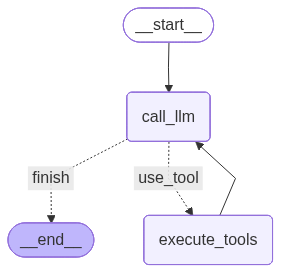

In [7]:
# 그래프 구조 확인
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print(app.get_graph().draw_mermaid())

---
## STEP 7. ✏️ 실행 & 결과 확인 — 직접 작성

`stream()`으로 실행해서 **어떤 Tool이 어떤 순서로 호출됐는지** 흐름을 확인한다.  
최소 3개의 질문을 실행해야 한다.


### 실행 흐름 출력 함수

아래 함수를 사용하면 각 노드의 실행 흐름을 보기 좋게 출력할 수 있다.


In [8]:
from langchain_core.messages import ToolMessage

def run_agent(question: str):
    """질문을 실행하고 흐름과 최종 답변을 출력한다."""
    print(f'\n{'='*60}')
    print(f'질문: {question}')
    print('='*60)

    final_answer = ''

    for chunk in app.stream(
        {'messages': [HumanMessage(content=question)]},
        config={'recursion_limit': 25}
    ):
        for node_name, update in chunk.items():
            for msg in update.get('messages', []):
                if hasattr(msg, 'tool_calls') and msg.tool_calls:
                    for tc in msg.tool_calls:
                        print(f'  🔍 Tool 호출: {tc["name"]}({list(tc["args"].values())})')
                elif isinstance(msg, ToolMessage):
                    print(f'  📥 Tool 결과: {msg.content[:80]}...')
                elif hasattr(msg, 'content') and msg.content:
                    final_answer = msg.content

    print(f'\n💬 최종 답변:')
    print(final_answer)

print('실행 함수 준비 완료')

SyntaxError: f-string: expecting '}' (2958491245.py, line 5)

### 질문 1


In [9]:
# TODO: 내 Agent 주제에 맞는 질문을 작성한다
#       반드시 실시간 정보가 필요한 질문이어야 한다 (Tavily가 필요한 이유)

run_agent('TODO: 첫 번째 질문을 여기에 작성하세요')

NameError: name 'run_agent' is not defined

### 질문 2


In [ ]:
run_agent('TODO: 두 번째 질문을 여기에 작성하세요')

### 질문 3


In [ ]:
run_agent('TODO: 세 번째 질문을 여기에 작성하세요')

### (선택) 추가 질문

더 실험해보고 싶은 질문이 있으면 자유롭게 추가한다.


In [ ]:
# TODO (선택): 추가 질문
# run_agent('...')